# AI contract parquet merge and feature check

This notebook merges all AI-contract parquet outputs, removes likely duplicate contract rows, and plots basic time-series features: contract counts, total USD contract value, and the same metrics for the five largest countries.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

OUTPUT_DIR = Path(r"D:\.01_projects\Tenderalpha_world_contract\00_code\ai_contract_outputs")
PARQUET_PATTERN = "ai_contracts_all_files*.parquet"
MERGED_OUTPUT = OUTPUT_DIR / "ai_contracts_merged_0507.parquet"

parquet_files = sorted(OUTPUT_DIR.glob(PARQUET_PATTERN))
parquet_files

[WindowsPath('D:/.01_projects/Tenderalpha_world_contract/00_code/ai_contract_outputs/ai_contracts_all_files.parquet'),
 WindowsPath('D:/.01_projects/Tenderalpha_world_contract/00_code/ai_contract_outputs/ai_contracts_all_files_01.parquet')]

In [3]:
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {OUTPUT_DIR} matching {PARQUET_PATTERN}")

frames = []
for path in parquet_files:
    part = pd.read_parquet(path)
    part["RESULT_PARQUET_FILE"] = path.name
    frames.append(part)

raw = pd.concat(frames, ignore_index=True)
print(f"Parquet files loaded: {len(parquet_files):,}")
print(f"Rows before dedupe: {len(raw):,}")
raw.head()

Parquet files loaded: 2
Rows before dedupe: 37,736


,ORIGIN,ORIGIN_ID,TENDER_BIZPORTAL_ID,TRANSACTION_BIZPORTAL_ID,CONTRACTING_ENTITY_BIZPORTAL_ID,CONTRACTING_ENTITY_NAME,CONTRACTING_ENTITY_COUNTRY,CONTRACTING_ENTITY_STATE,CONTRACTING_ENTITY_LOCATION,CONTRACTING_ENTITY_ADDRESS,CONTRACTING_ENTITY_POSTCODE,CONTRACTING_ENTITY_WEBSITE,TENDER_TITLE,TENDER_DESCRIPTION,TENDER_INDUSTRY_CODES,TENDER_FUNDING_ORIGIN_COUNTRY,TENDER_COUNTRY,TENDER_STATE,TENDER_LOCATION,TENDER_DATE_OF_AWARD,TENDER_DATE_OF_DISPATCH,TENDER_MIN_DELIVERY_DATE,TENDER_CONTRACT_START_DATE,TENDER_CONTRACT_END_DATE,TENDER_CURRENCY,TENDER_POTENTIAL_VALUE_OF_CONTRACT,TENDER_POTENTIAL_VALUE_OF_CONTRACT_USD,TENDER_CURRENT_EVENT_AMOUNT,TENDER_CURRENT_EVENT_AMOUNT_USD,TENDER_VALUE_OF_CONTRACT_TO_DATE,TENDER_VALUE_OF_CONTRACT_TO_DATE_USD,TENDER_BUDGET_EXECUTION_PERCENTAGE_TO_DATE,TENDER_BIDDERS_COUNT,TENDER_FRAMEWORK,TENDER_TYPE_OF_AUTHORITY,TENDER_TYPE_OF_CONTRACT,TENDER_TYPE_OF_PROCEDURE,TENDER_TYPE_OF_REGULATION,TENDER_TYPE_OF_BID,TENDER_AWARD_CRITERIA,TENDER_TYPE_OF_CONTRACT_PRICING,DIRECT_AWARDEE_BIZPORTAL_ID,DIRECT_AWARDEE_NAME,DIRECT_AWARDEE_UIC,DIRECT_AWARDEE_VAT_NUMBER,DIRECT_AWARDEE_COUNTRY,DIRECT_AWARDEE_STATE,DIRECT_AWARDEE_LOCATION,DIRECT_AWARDEE_ADDRESS,DIRECT_AWARDEE_POSTCODE,DIRECT_AWARDEE_WEBSITE,DIRECT_AWARDEE_LISTING_STATUS,DIRECT_AWARDEE_TICKER_SYMBOL,DIRECT_AWARDEE_STOCK_EXCHANGE_MIC,DIRECT_AWARDEE_STOCK_EXCHANGE_NAME,DIRECT_AWARDEE_STOCK_EXCHANGE_COUNTRY,DIRECT_AWARDEE_ISIN_NUMBER,DIRECT_AWARDEE_AMOUNT,DIRECT_AWARDEE_CURRENCY,DIRECT_AWARDEE_USD_AMOUNT,AWARDEE_PARENT_BIZPORTAL_ID,AWARDEE_PARENT_NAME,AWARDEE_PARENT_UIC,AWARDEE_PARENT_VAT_NUMBER,AWARDEE_PARENT_COUNTRY,AWARDEE_PARENT_STATE,AWARDEE_PARENT_LOCATION,AWARDEE_PARENT_ADDRESS,AWARDEE_PARENT_POSTCODE,AWARDEE_PARENT_WEBSITE,AWARDEE_PARENT_LISTING_STATUS,AWARDEE_PARENT_TICKER_SYMBOL,AWARDEE_PARENT_STOCK_EXCHANGE_MIC,AWARDEE_PARENT_STOCK_EXCHANGE_NAME,AWARDEE_PARENT_STOCK_EXCHANGE_COUNTRY,AWARDEE_PARENT_ISIN_NUMBER,SOURCE_FILE,SEARCH_TEXT,AI_MATCH_TERMS,AI_REVIEW_LABEL,PROCUREMENT_CONTENT,RESULT_PARQUET_FILE
0,US Procurement,2.00,"79,725,901.00","49,276,998.00","485,059.00",CENTERS FOR DISEASE CONTROL AND PREVENTION,US,,,,,,"RESEARCH AND DEVELOPMENT IN THE PHYSICAL, ENGI...",FY21 BAA MINE HEALTH AND SAFETY BIG DATA ANALY...,,US,US,MI,Houghton,2021-08-25,2021-08-25,2021-08-26,2021-09-01,2023-08-31,USD,"288,343.00","288,343.00","288,343.00","288,343.00","288,343.00","288,343.00",100.00,55.00,False,,Definitive Contract,BASIC RESEARCH,,,,FIRM FIXED PRICE,"188,344.00",MICHIGAN TECHNOLOGICAL UNIVERSITY,,,US,MI,Houghton,1400 TOWNSEND DR,499311200,,Unlisted,,,,,,NaN,,NaN,0.00,,,,,,,,,,,,,,,,unified-government-contract-awards_0_0_0.snapp...,"\nRESEARCH AND DEVELOPMENT IN THE PHYSICAL, EN...",core_ai_en: machine learning; broad_ai_en: big...,clear_ai_related,medical_lab_or_speech_recognition,ai_contracts_all_files.parquet
1,US Procurement,2.00,"46,222,643.00","31,045,246.00","38,122.00",DEPT OF THE AIR FORCE,US,,,,,,"DATA PROCESSING, HOSTING, AND RELATED SERVICES",IGF::OT::IGF TO ACQUIRE SOFTWARE ENGINEERING A...,72300000 - Data services,US,US,OH,Columbus,2018-03-14,2018-03-14,2018-03-15,2018-01-02,2023-07-01,USD,"23,879,687.04","23,879,687.04","-20,000.00","-20,000.00","4,045,031.04","4,045,031.04",16.94,1.00,False,,Definitive Contract,ONLY ONE SOURCE,,,,FIRM FIXED PRICE,"183,343.00",BATTELLE MEMORIAL INSTITUTE,,,US,OH,Columbus,505 KING AVENUE,432012696,www.battelle.org,Unlisted,,,,,,NaN,,NaN,0.00,,,,,,,,,,,,,,,,unified-government-contract-awards_0_0_0.snapp...,"\nDATA PROCESSING, HOSTING, AND RELATED SERVIC...",broad_ai_en: decision support system,clear_ai_related,facility_maintenance_security_postal,ai_contracts_all_files.parquet
2,US Procurement,2.00,"6,554,729.00","11,535,885.00","38,167.00",NATIONAL OCEANIC AND ATMOSPHERIC ADMINISTRATION,US,,,,,,"Research and Development in the Physical, Engi...",IGF::OT::IGF OTHER FUNCTIONS - THIS AWARD IS F...,73100000 - Research and experimental developme...,US,US,CA,GOLETA,2013-07-31,2013-07-31,2013-08-01,2013-07-31,

In [4]:
preferred_id_cols = [
    "ORIGIN",
    "ORIGIN_ID",
    "TENDER_BIZPORTAL_ID",
    "TRANSACTION_BIZPORTAL_ID",
    "DIRECT_AWARDEE_BIZPORTAL_ID",
]
dedupe_cols = [col for col in preferred_id_cols if col in raw.columns]

if dedupe_cols:
    df = raw.drop_duplicates(subset=dedupe_cols).copy()
else:
    df = raw.drop_duplicates().copy()

print(f"Dedupe columns: {dedupe_cols if dedupe_cols else 'all columns'}")
print(f"Rows after dedupe: {len(df):,}")
print(f"Duplicate rows removed: {len(raw) - len(df):,}")

Dedupe columns: ['ORIGIN', 'ORIGIN_ID', 'TENDER_BIZPORTAL_ID', 'TRANSACTION_BIZPORTAL_ID', 'DIRECT_AWARDEE_BIZPORTAL_ID']
Rows after dedupe: 36,622
Duplicate rows removed: 1,114


In [5]:
date_candidates = [
    "TENDER_DATE_OF_AWARD",
    "TENDER_DATE_OF_DISPATCH",
    "TENDER_CONTRACT_START_DATE",
]
value_candidates = [
    "TENDER_CURRENT_EVENT_AMOUNT_USD",
    "TENDER_VALUE_OF_CONTRACT_TO_DATE_USD",
    "TENDER_POTENTIAL_VALUE_OF_CONTRACT_USD",
    "DIRECT_AWARDEE_USD_AMOUNT",
]

date_cols = [col for col in date_candidates if col in df.columns]
value_cols = [col for col in value_candidates if col in df.columns]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")
for col in value_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["analysis_date"] = df[date_cols].bfill(axis=1).iloc[:, 0]
df["year"] = df["analysis_date"].dt.year
df["contract_value_usd"] = df[value_cols].bfill(axis=1).iloc[:, 0].fillna(0)

country_col = "TENDER_COUNTRY" if "TENDER_COUNTRY" in df.columns else "CONTRACTING_ENTITY_COUNTRY"
df["analysis_country"] = df[country_col].fillna("Unknown").replace("", "Unknown")

df.to_parquet(MERGED_OUTPUT, index=False)
print(f"Saved merged parquet: {MERGED_OUTPUT}")
print(f"Rows with analysis date: {df['analysis_date'].notna().sum():,}")
print(f"Rows with positive value: {(df['contract_value_usd'] > 0).sum():,}")

Saved merged parquet: D:\.01_projects\Tenderalpha_world_contract\00_code\ai_contract_outputs\ai_contracts_merged_0507.parquet
Rows with analysis date: 36,622
Rows with positive value: 34,117


In [6]:
summary = pd.Series({
    "contracts_total": len(df),
    "contracts_with_date": df["analysis_date"].notna().sum(),
    "contracts_with_positive_value": (df["contract_value_usd"] > 0).sum(),
    "total_value_usd": df["contract_value_usd"].sum(),
    "median_value_usd": df.loc[df["contract_value_usd"] > 0, "contract_value_usd"].median(),
    "countries": df["analysis_country"].nunique(),
})
summary

contracts_total                          36,622.00
contracts_with_date                      36,622.00
contracts_with_positive_value            34,117.00
total_value_usd                 234,556,181,591.35
median_value_usd                        148,274.00
countries                                    68.00
dtype: float64

In [7]:
annual = (
    df.dropna(subset=["year"])
    .groupby("year", as_index=False)
    .agg(
        contracts=("year", "size"),
        total_value_usd=("contract_value_usd", "sum"),
    )
    .sort_values("year")
)

annual

,year,contracts,total_value_usd
0,2009,3,"409,840.02"
1,2010,651,"157,601,042.91"
2,2011,1047,"318,740,173.24"
3,2012,1136,"971,375,247.39"
4,2013,1185,"1,825,730,360.01"
5,2014,1407,"1,714,859,758.11"
6,2015,1620,"1,957,661,684.01"
7,2016,1791,"7,072,669,562.15"
8,2017,2108,"2,572,750,890.43"
9,2018,2612,"2,268,217,104.75"


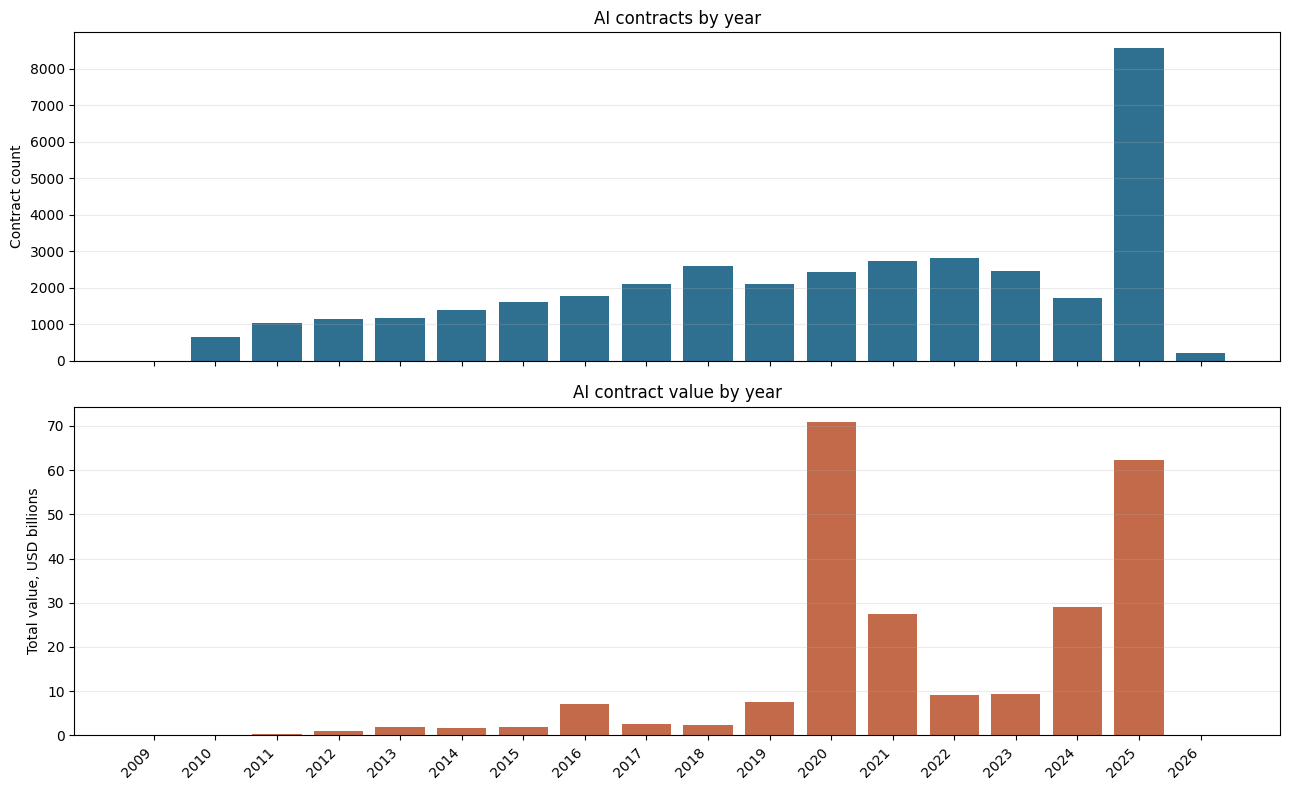

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].bar(annual["year"].astype(str), annual["contracts"], color="#2F6F8F")
axes[0].set_title("AI contracts by year")
axes[0].set_ylabel("Contract count")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(annual["year"].astype(str), annual["total_value_usd"] / 1e9, color="#C26A4A")
axes[1].set_title("AI contract value by year")
axes[1].set_ylabel("Total value, USD billions")
axes[1].grid(axis="y", alpha=0.25)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
top_countries = (
    df[df["analysis_country"] != "Unknown"]
    .groupby("analysis_country")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

country_year = (
    df[df["analysis_country"].isin(top_countries)]
    .dropna(subset=["year"])
    .groupby(["year", "analysis_country"], as_index=False)
    .agg(
        contracts=("analysis_country", "size"),
        total_value_usd=("contract_value_usd", "sum"),
    )
)

print(top_countries)
country_year.head()

['US', 'KR', 'CN', 'GB', 'CO']


,year,analysis_country,contracts,total_value_usd
0,2009,GB,1,"93,750.00"
1,2010,GB,7,"5,329,002.21"
2,2010,KR,185,"2,499,788.97"
3,2010,US,412,"100,223,997.84"
4,2011,GB,7,"3,734,564.47"


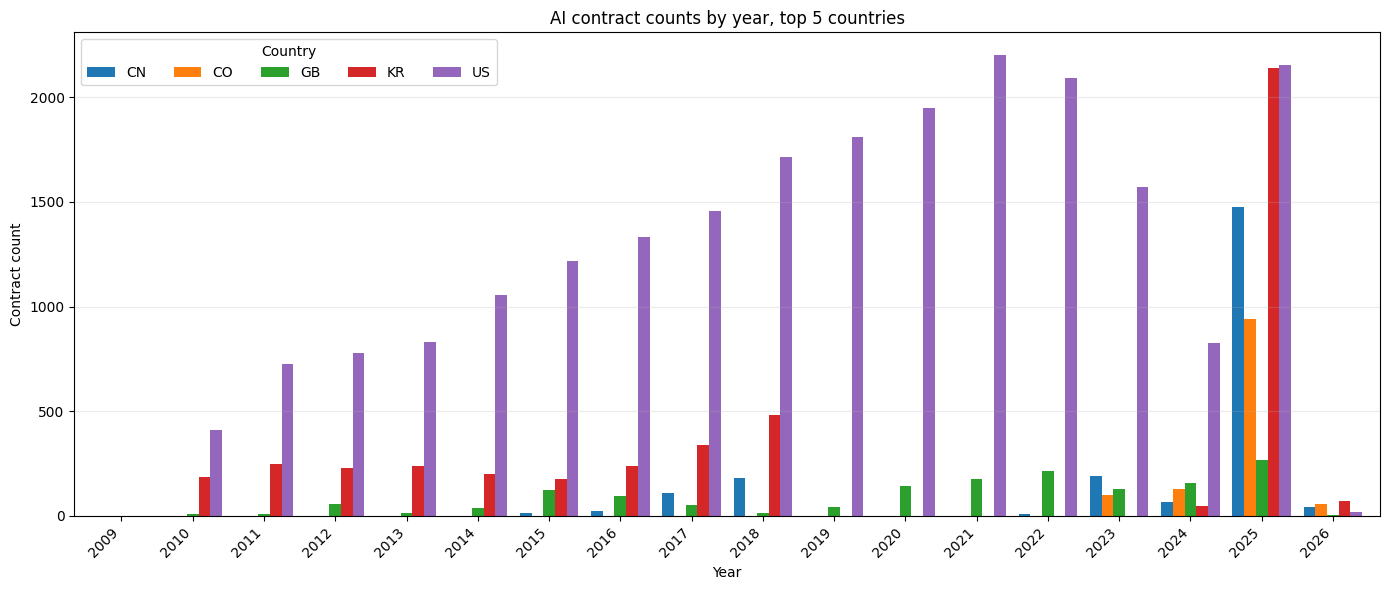

In [10]:
count_pivot = country_year.pivot(index="year", columns="analysis_country", values="contracts").fillna(0)

ax = count_pivot.plot(kind="bar", figsize=(14, 6), width=0.82)
ax.set_title("AI contract counts by year, top 5 countries")
ax.set_xlabel("Year")
ax.set_ylabel("Contract count")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Country", ncols=min(5, len(top_countries)))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

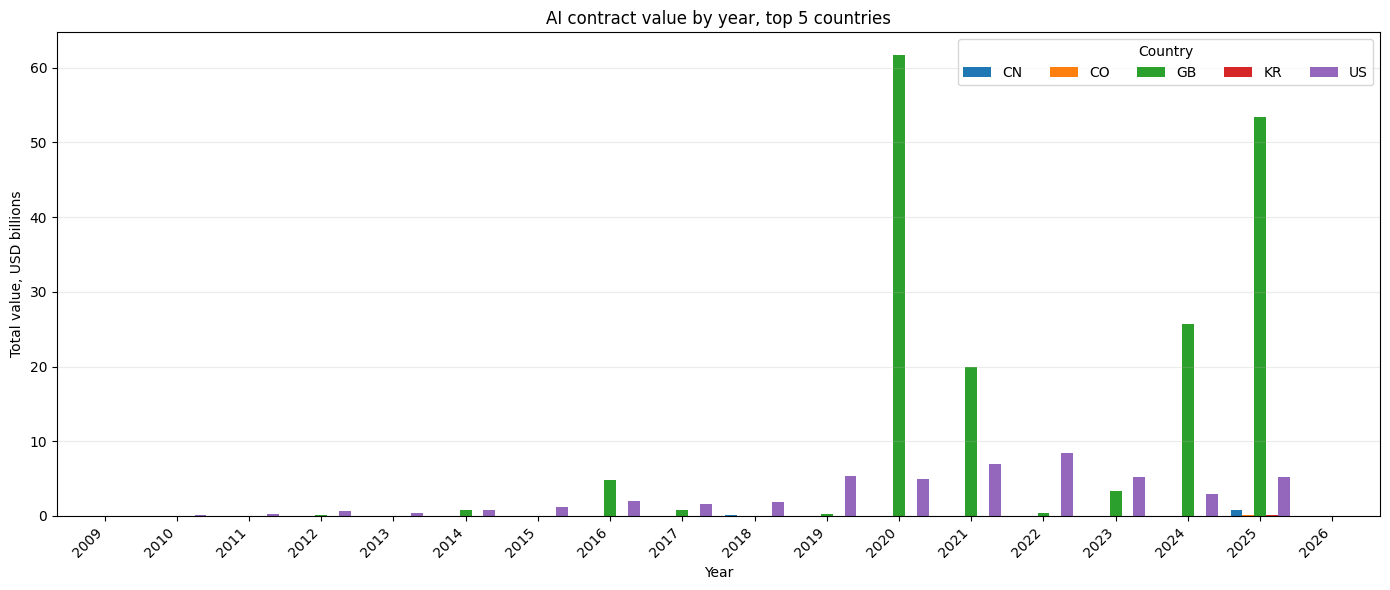

In [11]:
value_pivot = country_year.pivot(index="year", columns="analysis_country", values="total_value_usd").fillna(0) / 1e9

ax = value_pivot.plot(kind="bar", figsize=(14, 6), width=0.82)
ax.set_title("AI contract value by year, top 5 countries")
ax.set_xlabel("Year")
ax.set_ylabel("Total value, USD billions")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Country", ncols=min(5, len(top_countries)))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
country_summary = (
    df.groupby("analysis_country", as_index=False)
    .agg(
        contracts=("analysis_country", "size"),
        total_value_usd=("contract_value_usd", "sum"),
        median_value_usd=("contract_value_usd", lambda s: s[s > 0].median()),
    )
    .sort_values(["contracts", "total_value_usd"], ascending=False)
)

country_summary.head(20)

,analysis_country,contracts,total_value_usd,median_value_usd
63,US,22152,"47,878,300,992.51","201,871.00"
34,KR,4597,"240,683,730.36","8,462.36"
10,CN,2113,"1,020,173,709.22","206,468.97"
21,GB,1531,"171,280,479,009.28","777,317.26"
11,CO,1226,"105,058,738.09","12,978.06"
53,RU,754,"128,567,989.47","22,379.62"
2,AU,489,"178,254,722.06","75,660.00"
14,DE,428,"1,730,078,021.68","361,159.91"
20,FR,304,"964,023,602.61","600,545.55"
61,UA,297,"13,006,718.71","2,729.64"


## AI term word clouds

The next cells use `AI_MATCH_TERMS` to show which AI-related terms drove the matches overall and for selected countries. If the `wordcloud` package is available, the charts are true word clouds; otherwise the notebook falls back to a matplotlib text cloud.

In [13]:
import math
import random
import re
from collections import Counter

try:
    from wordcloud import WordCloud
except ImportError:
    WordCloud = None

COUNTRY_LABELS = {
    "US": "United States",
    "CN": "China",
    "IN": "India",
    "GB": "United Kingdom",
    "KR": "South Korea",
}

TERM_REPLACEMENTS = {
    "ai": "AI",
    "a i": "AI",
    "llm": "LLM",
    "nlp": "NLP",
    "rpa": "RPA",
    "genai": "GenAI",
}

def clean_ai_term(term):
    term = str(term).split(":", 1)[-1]
    term = term.replace("\\b", " ").replace("\\w*", " ")
    term = term.replace("\\.", ".").replace("[ -]?", " ")
    term = re.sub(r"[^0-9A-Za-z]+", " ", term).strip().lower()
    term = re.sub(r"\s+", " ", term)
    return TERM_REPLACEMENTS.get(term, term.title())

def parse_ai_match_terms(value):
    if pd.isna(value) or not str(value).strip():
        return []
    terms = [clean_ai_term(part) for part in str(value).split(";")]
    return [term for term in terms if term and len(term) > 1]

def term_counter(frame):
    counter = Counter()
    for value in frame.get("AI_MATCH_TERMS", pd.Series(dtype="object")).dropna():
        counter.update(parse_ai_match_terms(value))
    return counter

def plot_word_cloud_from_frequencies(freq, title, ax=None, max_words=80):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(title)
    ax.axis("off")

    freq = Counter({k: v for k, v in freq.items() if v > 0})
    if not freq:
        ax.text(0.5, 0.5, "No matched terms", ha="center", va="center", fontsize=14)
        return ax

    if WordCloud is not None:
        wc = WordCloud(
            width=1200,
            height=650,
            background_color="white",
            colormap="tab20c",
            max_words=max_words,
            random_state=42,
            collocations=False,
        ).generate_from_frequencies(freq)
        ax.imshow(wc, interpolation="bilinear")
        return ax

    rng = random.Random(42)
    top_terms = freq.most_common(max_words)
    max_count = top_terms[0][1]
    colors = plt.cm.tab20c([i % 20 for i in range(len(top_terms))])
    for i, (term, count) in enumerate(top_terms):
        size = 9 + 34 * math.sqrt(count / max_count)
        x = rng.uniform(0.08, 0.92)
        y = rng.uniform(0.10, 0.90)
        ax.text(x, y, term, fontsize=size, color=colors[i], ha="center", va="center", alpha=0.9, transform=ax.transAxes)
    return ax

overall_ai_terms = term_counter(df)
pd.DataFrame(overall_ai_terms.most_common(30), columns=["term", "count"])

,term,count
0,Artificial Intelligence,8351
1,Machine Learning,3929
2,AI,2471
3,Data Science,2210
4,Algorithm Development,1919
5,Ocr,1899
6,Decision Support System,1369
7,Autonomous System,1336
8,Predictive Model,1299
9,Intelligent System,997


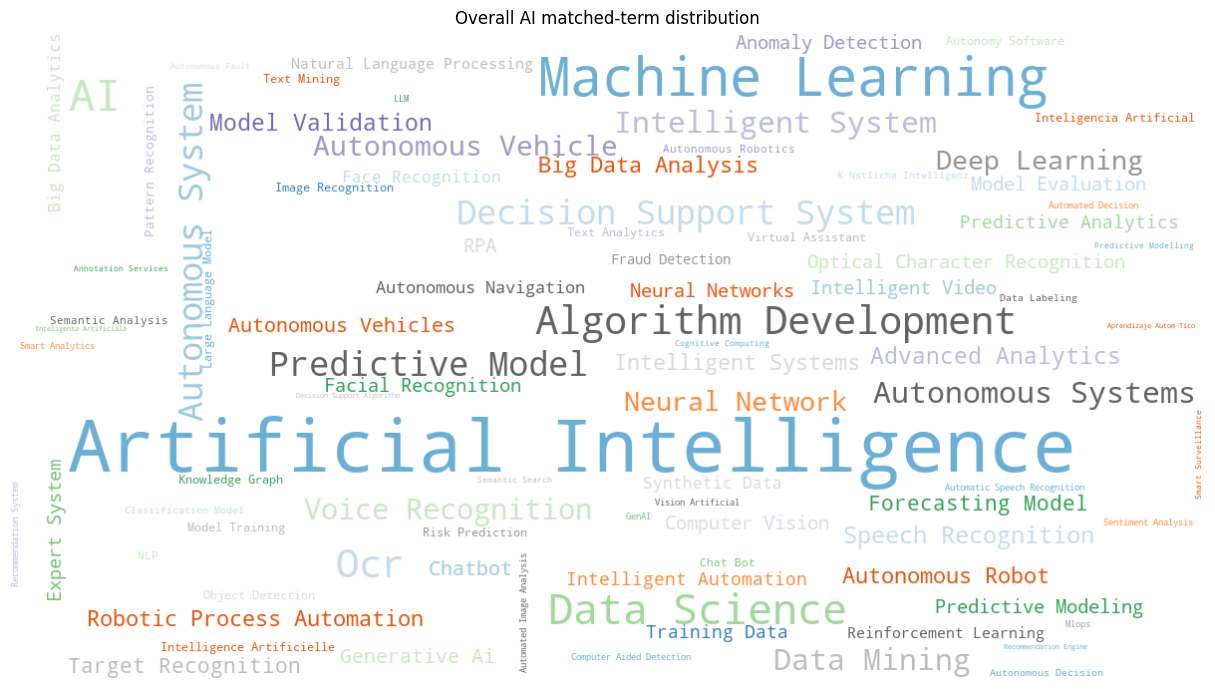

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
plot_word_cloud_from_frequencies(overall_ai_terms, "Overall AI matched-term distribution", ax=ax, max_words=90)
plt.tight_layout()
plt.show()

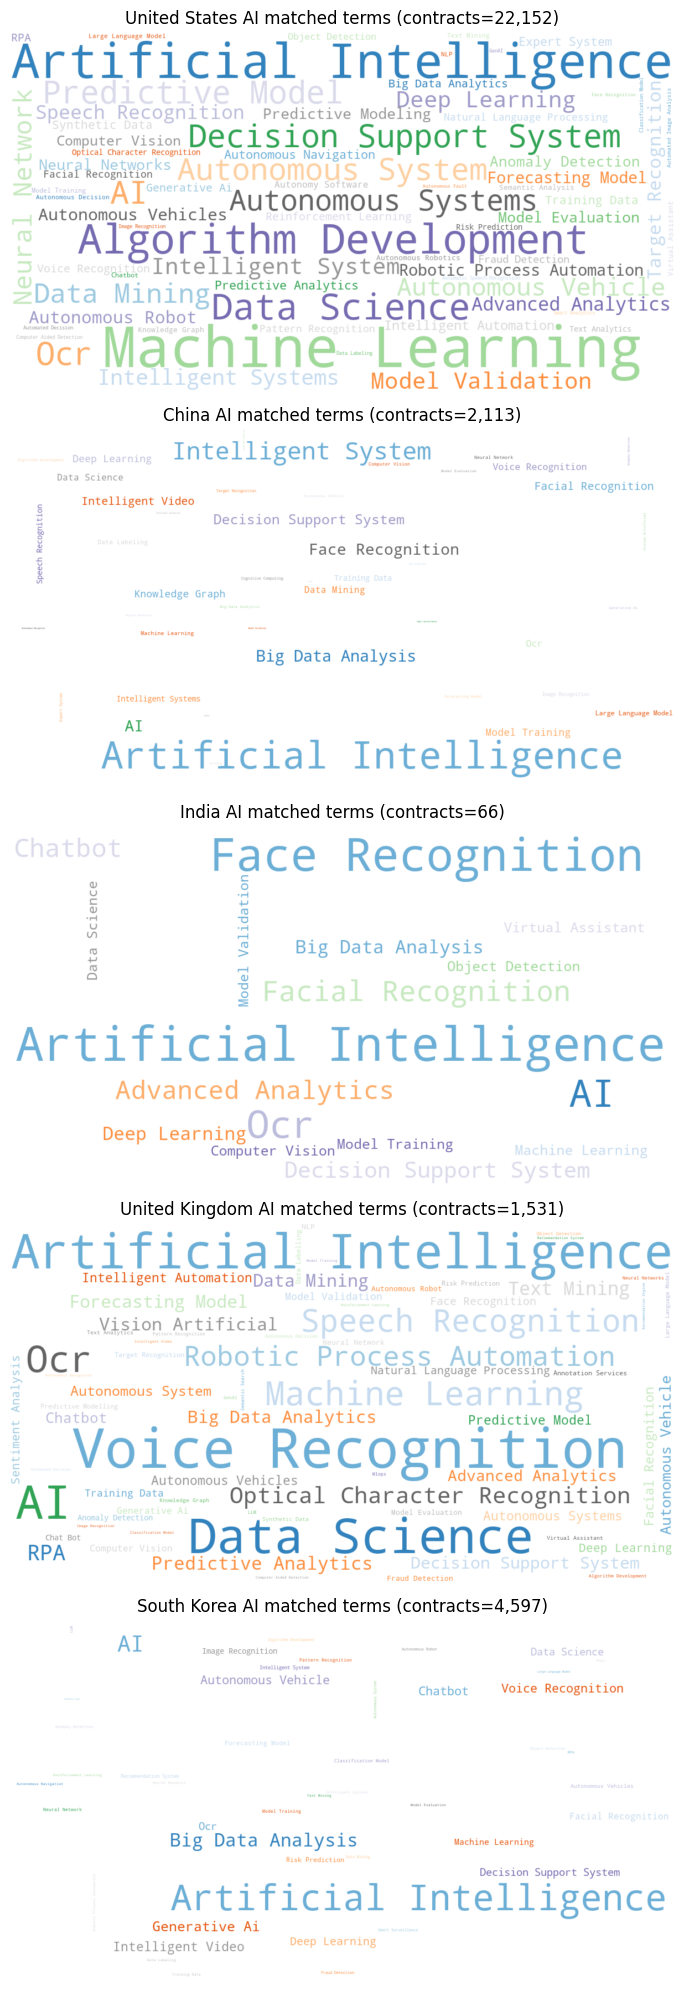

In [15]:
selected_countries = ["US", "CN", "IN", "GB", "KR"]

fig, axes = plt.subplots(len(selected_countries), 1, figsize=(14, 4 * len(selected_countries)))
for ax, country in zip(axes, selected_countries):
    country_frame = df[df["analysis_country"] == country]
    freq = term_counter(country_frame)
    title = f"{COUNTRY_LABELS.get(country, country)} AI matched terms (contracts={len(country_frame):,})"
    plot_word_cloud_from_frequencies(freq, title, ax=ax, max_words=70)

plt.tight_layout()
plt.show()

In [16]:
country_term_tables = []
for country in ["US", "CN", "IN", "GB", "KR"]:
    freq = term_counter(df[df["analysis_country"] == country])
    top = pd.DataFrame(freq.most_common(15), columns=["term", "count"])
    top.insert(0, "country", country)
    country_term_tables.append(top)

country_terms_top = pd.concat(country_term_tables, ignore_index=True)
country_terms_top

,country,term,count
0,US,Machine Learning,3259
1,US,Artificial Intelligence,2743
2,US,Algorithm Development,1896
3,US,Data Science,1444
4,US,Decision Support System,1071
...,...,...,...
70,KR,Ocr,93
71,KR,Decision Support System,92
72,KR,Facial Recognition,63
73,KR,Machine Learning,55


## China rows

In [19]:
china_rows = df[df["analysis_country"] == "CN"].copy()

print(f"China rows: {len(china_rows):,}")

display_cols = [
    "ORIGIN",
    "ORIGIN_ID",
    "TENDER_BIZPORTAL_ID",
    "TRANSACTION_BIZPORTAL_ID",
    "TENDER_DATE_OF_AWARD",
    "TENDER_TITLE",
    "TENDER_DESCRIPTION",
    "AI_MATCH_TERMS",
    "contract_value_usd",
    "RESULT_PARQUET_FILE",
]
display_cols = [col for col in display_cols if col in china_rows.columns]

china_rows[display_cols].head(100)

China rows: 2,113


,ORIGIN,ORIGIN_ID,TENDER_BIZPORTAL_ID,TRANSACTION_BIZPORTAL_ID,TENDER_DATE_OF_AWARD,TENDER_TITLE,TENDER_DESCRIPTION,AI_MATCH_TERMS,contract_value_usd,RESULT_PARQUET_FILE
92,China Procurement,13.00,"190,293,284.00",0.00,2025-01-27,Gaoyou Municipal Health Commission's Artificia...,Gaoyou Municipal Health Commission's Announcem...,core_ai_en: artificial intelligence; core_ai_e...,"340,645.11",ai_contracts_all_files.parquet
99,China Procurement,13.00,"116,604,098.00",0.00,2024-01-19,Clinical auxiliary decision -making support sy...,Artificial Intelligence -based clinical auxili...,core_ai_en: artificial intelligence,"165,563.44",ai_contracts_all_files.parquet
128,China Procurement,13.00,"191,905,589.00",0.00,2025-02-11,Artificial Intelligence Exhibition Hall Exhibi...,Sichuan Science and Technology Museum Artifici...,core_ai_en: artificial intelligence,"136,157.79",ai_contracts_all_files.parquet
209,China Procurement,13.00,"119,863,947.00",0.00,2024-04-08,School bus dynamic information supervision int...,School bus dynamic information supervision int...,broad_ai_en: intelligent video,"383,709.51",ai_contracts_all_files.parquet
262,China Procurement,13.00,"202,303,048.00",0.00,2025-08-08,General Factor Method-Artificial Intelligence-...,General Factor Method - Artificial Intelligenc...,core_ai_en: artificial intelligence,"483,714.84",ai_contracts_all_files.parquet
...,...,...,...,...,...,...,...,...,...,...
2163,China Procurement,13.00,"199,861,974.00",0.00,2025-07-10,The first batch of AI course construction serv...,Jianghan University's first batch of AI course...,core_ai_en: \bAI\b; broad_ai_en: knowledge graph,"166,195.27",ai_contracts_all_files.parquet
2164,China Procurement,13.00,"200,544,099.00",0.00,2025-07-17,Guangdong Medical University Medical Artificia...,Guangdong Medical University Medical Artificia...,core_ai_en: artificial intelligence,"1,371,160.39",ai_contracts_all_files.parquet
2175,China Procurement,13.00,"204,164,654.00",0.00,2025-09-16,Procurement of electronic instruments and equi...,Chongqing Technology and Business University S...,core_ai_en: artificial intelligence,"980,567.59",ai_contracts_all_files.parquet
2179,China Procurement,13.00,"205,356,637.00",0.00,2025-10-14,Intelligent Speech Recognition Project of Binz...,Announcement of the Winning Bid (Transaction) ...,core_ai_en: speech recognition,"68,636.95",ai_contracts_all_files.parquet


## Contracting agency analysis

These cells summarize which contracting entities/agencies are buying AI-related goods and services, ranked by contract count and total USD value.

In [27]:
agency_col = "CONTRACTING_ENTITY_NAME"
agency_country_col = "CONTRACTING_ENTITY_COUNTRY" if "CONTRACTING_ENTITY_COUNTRY" in df.columns else "analysis_country"

agency_df = df.copy()
agency_df["agency_name"] = (
    agency_df[agency_col]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .replace("", "Unknown")
)
agency_df["agency_country"] = (
    agency_df[agency_country_col]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .replace("", "Unknown")
)

agency_summary = (
    agency_df.groupby(["agency_name", "agency_country"], as_index=False)
    .agg(
        contracts=("agency_name", "size"),
        total_value_usd=("contract_value_usd", "sum"),
        median_value_usd=("contract_value_usd", lambda s: s[s > 0].median()),
        first_award_date=("analysis_date", "min"),
        last_award_date=("analysis_date", "max"),
        source_countries=("analysis_country", lambda s: ", ".join(sorted(set(s.dropna().astype(str)))[:8])),
    )
)

agency_summary_by_count = agency_summary.sort_values(
    ["contracts", "total_value_usd"], ascending=False
).reset_index(drop=True)
agency_summary_by_count.head(30)

,agency_name,agency_country,contracts,total_value_usd,median_value_usd,first_award_date,last_award_date,source_countries
0,NATIONAL AERONAUTICS AND SPACE ADMINISTRATION,US,7736,"7,049,457,251.55","136,560.50",2010-01-04,2026-01-14,"CA, GB, NL, US"
1,DEPT OF THE AIR FORCE,US,2506,"2,223,597,823.37","319,549.06",2010-01-05,2025-11-26,"DE, GB, US"
2,DEPT OF THE ARMY,US,1381,"24,429,045,226.70","522,817.99",2010-02-12,2025-09-30,"AU, CA, DE, GB, KR, MY, US, UY"
3,Department of Defense,US,1357,"1,486,290,728.87","210,000.00",2010-04-30,2025-08-26,"AU, IT, KR, SG, US"
4,DEPT OF THE NAVY,US,1089,"1,205,887,564.25","358,589.04",2010-02-05,2025-12-16,"BH, GB, US"
5,DEFENSE ADVANCED RESEARCH PROJECTS AGENCY (DA...,US,725,"1,069,949,801.46","601,091.50",2010-02-04,2025-12-12,"GB, US"
6,"Seoul Artificial Intelligence High School, Seo...",KR,723,"7,866,134.91","2,720.13",2010-01-08,2026-01-09,KR
7,Seoul Metropolitan Office of Education Kwangwo...,KR,627,"7,109,099.84","6,341.74",2010-01-14,2026-01-13,KR
8,"VETERANS AFFAIRS, DEPARTMENT OF",US,511,"412,335,080.41","99,381.02",2010-02-04,2026-01-08,US
9,NATIONAL INSTITUTES OF HEALTH,US,438,"361,211,270.20","173,773.86",2010-04-07,2026-01-13,"GB, US"


In [28]:
agency_summary_by_value = agency_summary.sort_values(
    ["total_value_usd", "contracts"], ascending=False
).reset_index(drop=True)
agency_summary_by_value.head(30)

,agency_name,agency_country,contracts,total_value_usd,median_value_usd,first_award_date,last_award_date,source_countries
0,NHS Supply Chain Operated by DHL Supply Chain ...,GB,74,"59,526,096,878.92","804,406,714.58",2020-12-01,2020-12-01,GB
1,NHS Shared Business Services Ltd (NHS SBS),GB,173,"51,213,848,459.28","277,475,200.00",2012-03-01,2025-12-15,GB
2,Collaborative Procurement Partnership LLP (act...,GB,54,"49,327,680,780.00","913,475,570.00",2025-06-25,2025-06-25,GB
3,DEPT OF THE ARMY,US,1381,"24,429,045,226.70","522,817.99",2010-02-12,2025-09-30,"AU, CA, DE, GB, KR, MY, US, UY"
4,NATIONAL AERONAUTICS AND SPACE ADMINISTRATION,US,7736,"7,049,457,251.55","136,560.50",2010-01-04,2026-01-14,"CA, GB, NL, US"
5,The Minister for the Cabinet Office acting thr...,GB,108,"3,193,627,686.00","351,351,364.00",2015-02-17,2020-06-02,GB
6,NHS Commercial Solutions,GB,12,"2,924,714,400.00","243,726,200.00",2023-01-19,2023-01-19,GB
7,DEPT OF THE AIR FORCE,US,2506,"2,223,597,823.37","319,549.06",2010-01-05,2025-11-26,"DE, GB, US"
8,DEPT OF DEFENSE,US,350,"1,811,858,343.02","658,031.72",2018-05-22,2025-09-15,US
9,The Office of Government Procurement,IE,30,"1,689,395,037.60","91,270,232.00",2016-11-01,2020-10-27,IE


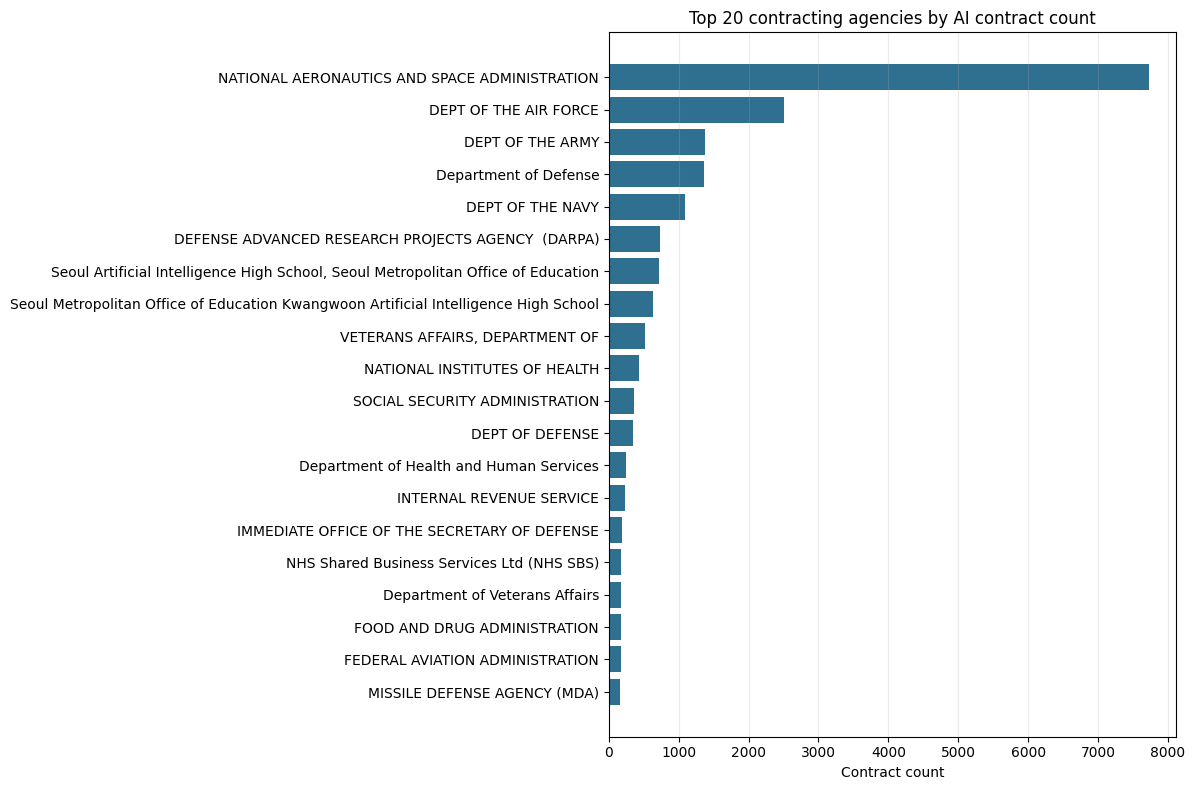

In [29]:
top_n = 20
plot_count = agency_summary_by_count.head(top_n).sort_values("contracts")

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(plot_count["agency_name"], plot_count["contracts"], color="#2F6F8F")
ax.set_title(f"Top {top_n} contracting agencies by AI contract count")
ax.set_xlabel("Contract count")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

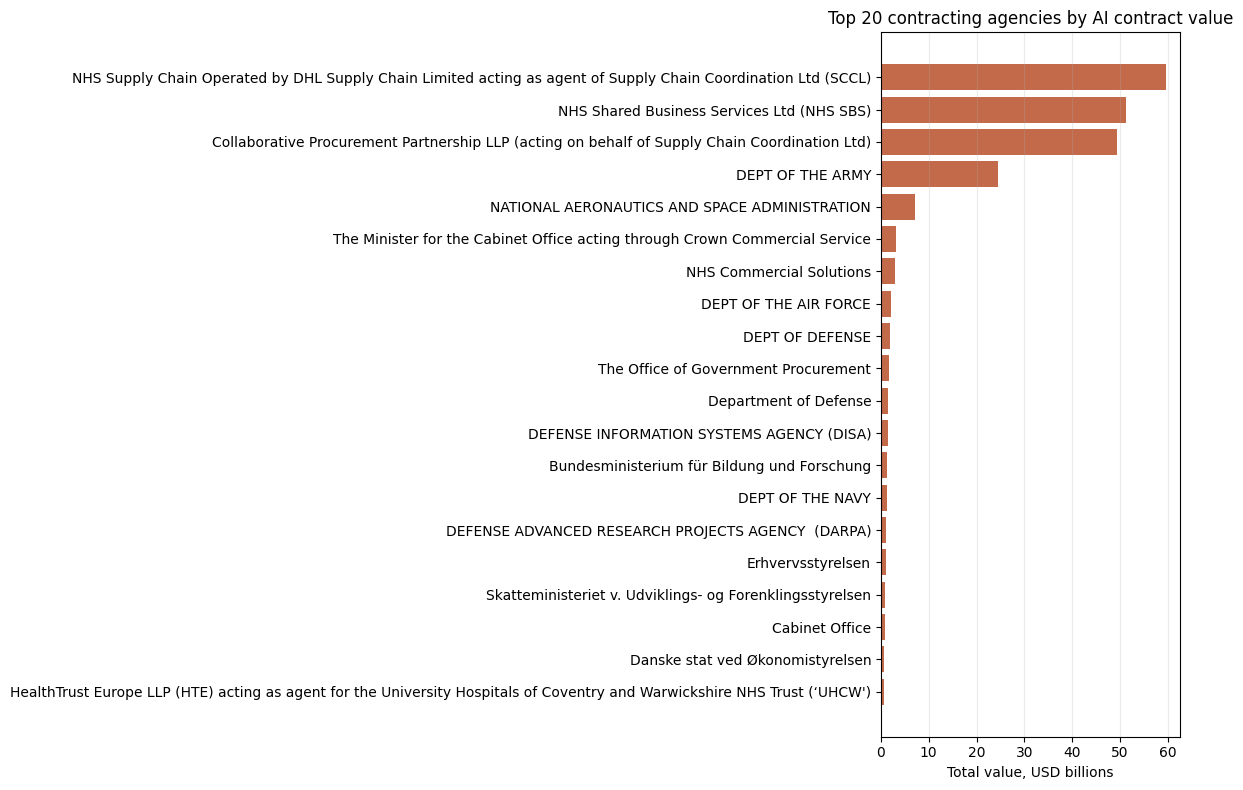

In [30]:
top_n = 20
plot_value = agency_summary_by_value.head(top_n).sort_values("total_value_usd")

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(plot_value["agency_name"], plot_value["total_value_usd"] / 1e9, color="#C26A4A")
ax.set_title(f"Top {top_n} contracting agencies by AI contract value")
ax.set_xlabel("Total value, USD billions")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

In [31]:
agency_country_summary = (
    agency_df.groupby("agency_country", as_index=False)
    .agg(
        agencies=("agency_name", "nunique"),
        contracts=("agency_name", "size"),
        total_value_usd=("contract_value_usd", "sum"),
    )
    .sort_values(["contracts", "total_value_usd"], ascending=False)
)

agency_country_summary.head(20)

,agency_country,agencies,contracts,total_value_usd
47,US,179,22336,"47,992,147,183.57"
28,KR,889,4588,"239,684,212.52"
9,CN,1469,2113,"1,020,173,709.22"
19,GB,358,1467,"171,062,909,434.21"
10,CO,366,1225,"105,017,058.09"
40,RU,528,754,"128,567,989.47"
2,AU,52,456,"105,415,565.62"
13,DE,284,455,"1,744,694,905.74"
18,FR,152,341,"984,563,651.19"
16,ES,182,318,"313,252,489.93"


In [32]:
selected_country_agencies = ["US", "CN", "IN", "GB", "KR"]

country_agency_top = []
for country in selected_country_agencies:
    top = (
        agency_summary[agency_summary["agency_country"] == country]
        .sort_values(["contracts", "total_value_usd"], ascending=False)
        .head(15)
        .copy()
    )
    top.insert(0, "rank_country", country)
    country_agency_top.append(top)

country_agency_top = pd.concat(country_agency_top, ignore_index=True)
country_agency_top[[
    "rank_country",
    "agency_name",
    "contracts",
    "total_value_usd",
    "median_value_usd",
    "first_award_date",
    "last_award_date",
]]

,rank_country,agency_name,contracts,total_value_usd,median_value_usd,first_award_date,last_award_date
0,US,NATIONAL AERONAUTICS AND SPACE ADMINISTRATION,7736,"7,049,457,251.55","136,560.50",2010-01-04,2026-01-14
1,US,DEPT OF THE AIR FORCE,2506,"2,223,597,823.37","319,549.06",2010-01-05,2025-11-26
2,US,DEPT OF THE ARMY,1381,"24,429,045,226.70","522,817.99",2010-02-12,2025-09-30
3,US,Department of Defense,1357,"1,486,290,728.87","210,000.00",2010-04-30,2025-08-26
4,US,DEPT OF THE NAVY,1089,"1,205,887,564.25","358,589.04",2010-02-05,2025-12-16
...,...,...,...,...,...,...,...
70,KR,Seoul,50,"7,138,260.03","32,193.71",2010-05-19,2025-12-23
71,KR,Agricultural Cooperative Federation,50,"363,724.99","2,497.49",2025-06-30,2026-01-09
72,KR,Jeonbuk Special Self-Governing Province Office...,38,"819,434.67","4,295.01",2025-05-20,2026-01-09
73,KR,Korea Transportation Safety Authority Automobi...,37,"1,220,212.51","16,459.14",2014-08-26,2025-12-30


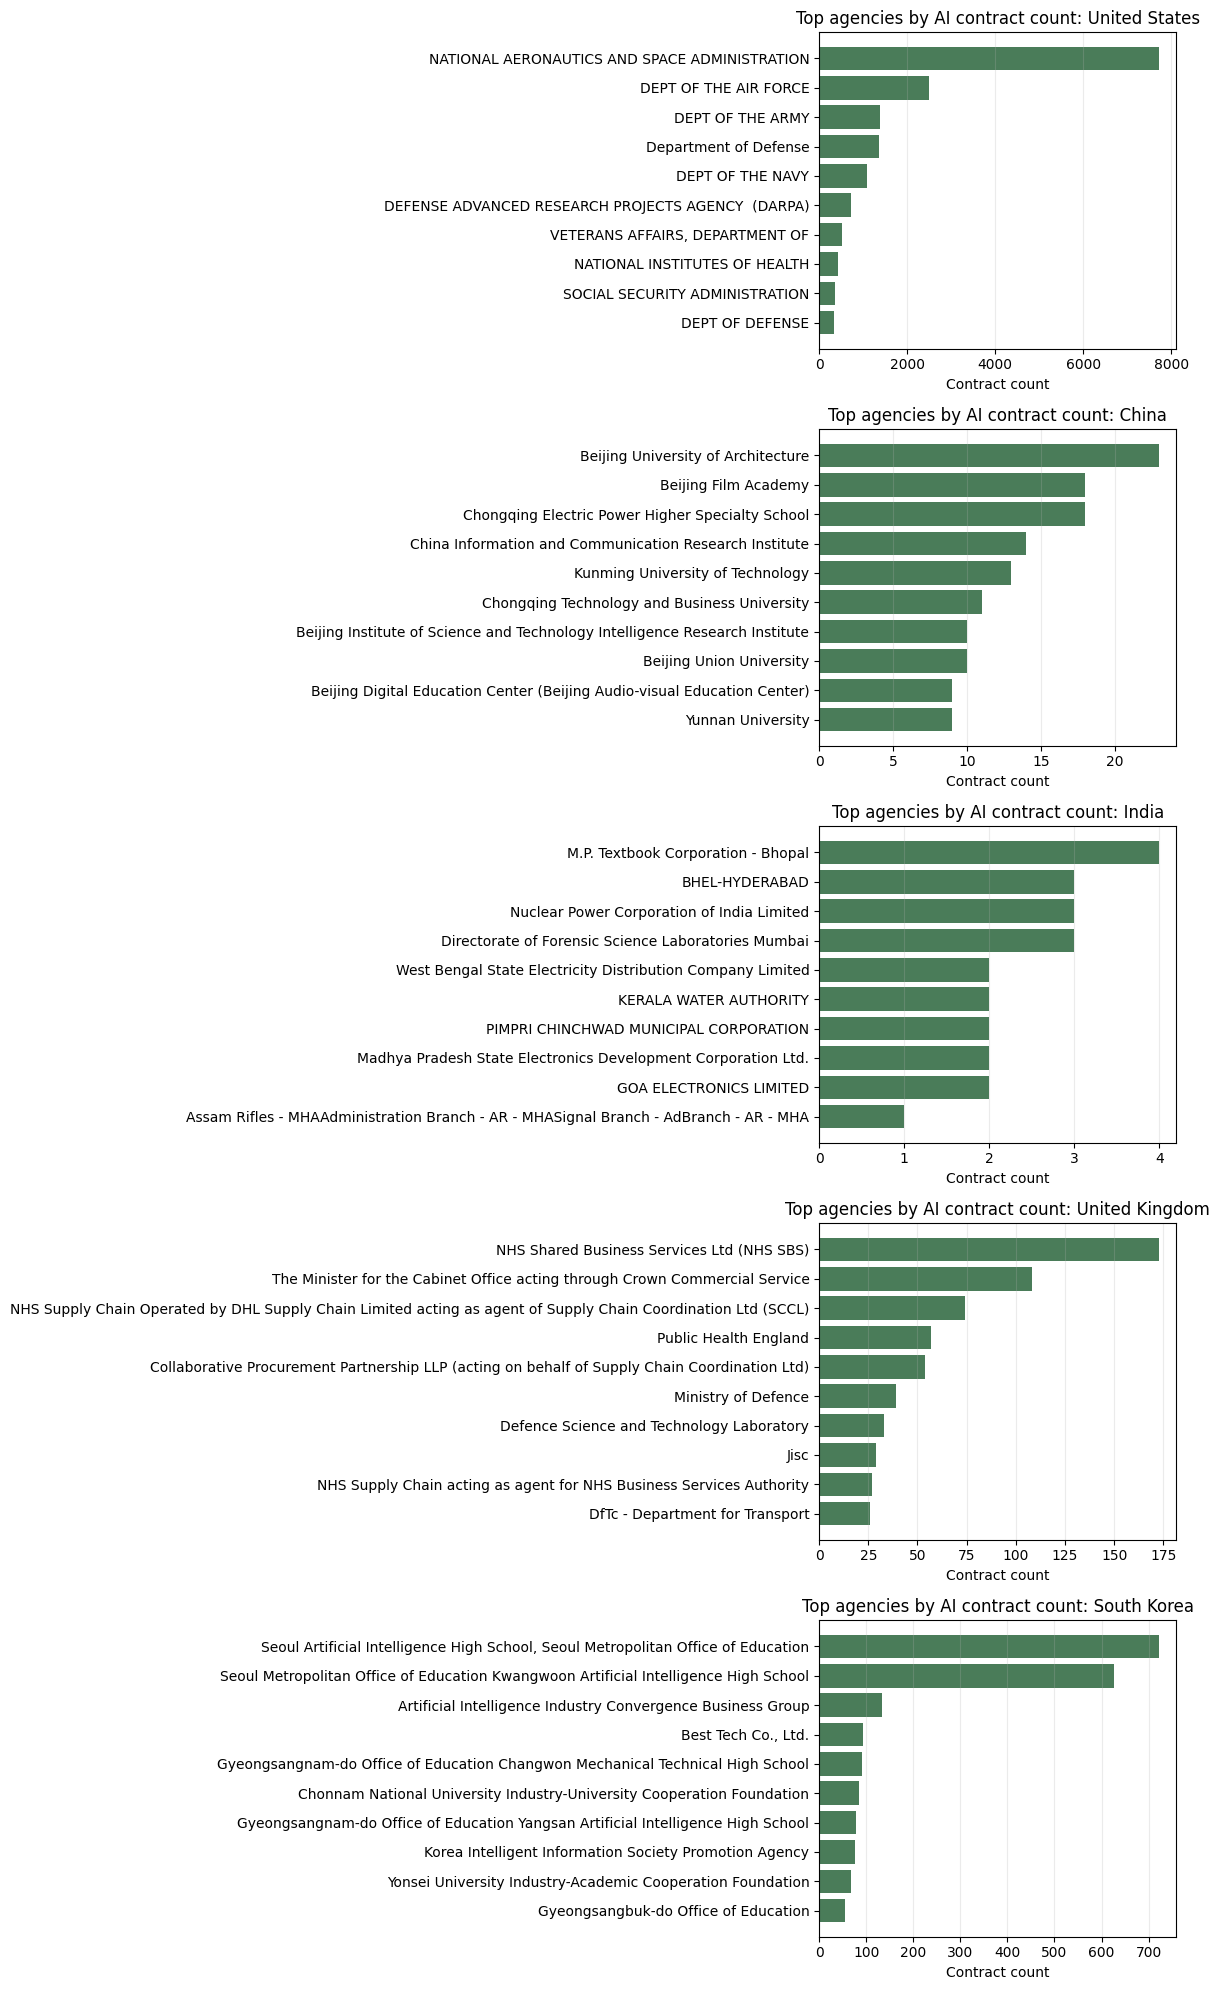

In [33]:
fig, axes = plt.subplots(len(selected_country_agencies), 1, figsize=(12, 4 * len(selected_country_agencies)))

for ax, country in zip(axes, selected_country_agencies):
    plot_data = (
        agency_summary[agency_summary["agency_country"] == country]
        .sort_values(["contracts", "total_value_usd"], ascending=False)
        .head(10)
        .sort_values("contracts")
    )
    ax.barh(plot_data["agency_name"], plot_data["contracts"], color="#4A7C59")
    ax.set_title(f"Top agencies by AI contract count: {COUNTRY_LABELS.get(country, country)}")
    ax.set_xlabel("Contract count")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## UN EGDI and AI contract volume correlation

These cells merge the AI contract totals with the UN E-Government Development Index data in `01_data`. The contract data uses ISO2 country codes, while EGDI uses ISO3 codes, so the first cell creates a mapping and reports unmatched countries.

In [34]:
import numpy as np

EGDI_PATH = Path("../01_data/UN_EGDI.csv")
if not EGDI_PATH.exists():
    EGDI_PATH = Path(r"D:/.01_projects/Tenderalpha_world_contract/01_data/UN_EGDI.csv")

egdi_raw = pd.read_csv(EGDI_PATH)
egdi_raw["TIME_PERIOD"] = pd.to_numeric(egdi_raw["TIME_PERIOD"], errors="coerce").astype("Int64")
egdi_raw["OBS_VALUE"] = pd.to_numeric(egdi_raw["OBS_VALUE"], errors="coerce")

egdi = (
    egdi_raw[egdi_raw["INDICATOR"] == "UN_EGDI_EGDI"]
    .dropna(subset=["REF_AREA", "TIME_PERIOD", "OBS_VALUE"])
    .copy()
)

egdi = egdi.rename(
    columns={
        "REF_AREA": "country_iso3",
        "REF_AREA_LABEL": "country_name",
        "TIME_PERIOD": "year",
        "OBS_VALUE": "egdi",
    }
)[["country_iso3", "country_name", "year", "egdi"]]

print(f"EGDI rows: {len(egdi):,}")
print(f"EGDI years: {egdi['year'].min()}-{egdi['year'].max()}")
egdi.head()

EGDI rows: 2,340
EGDI years: 2003-2024


,country_iso3,country_name,year,egdi
0,IRQ,Iraq,2003,0.00
1,IRL,Ireland,2003,0.70
2,ISR,Israel,2003,0.66
3,ITA,Italy,2003,0.69
4,JAM,Jamaica,2003,0.43


In [35]:
ISO2_TO_ISO3 = {
    "AR": "ARG", "AT": "AUT", "AU": "AUS", "BE": "BEL", "BG": "BGR", "BH": "BHR",
    "BR": "BRA", "CA": "CAN", "CH": "CHE", "CL": "CHL", "CN": "CHN", "CO": "COL",
    "CY": "CYP", "CZ": "CZE", "DE": "DEU", "DK": "DNK", "EE": "EST", "EG": "EGY",
    "ES": "ESP", "FI": "FIN", "FR": "FRA", "GB": "GBR", "GH": "GHA", "GR": "GRC",
    "HK": "HKG", "HR": "HRV", "HU": "HUN", "IE": "IRL", "IL": "ISR", "IN": "IND",
    "IQ": "IRQ", "IS": "ISL", "IT": "ITA", "JP": "JPN", "KR": "KOR", "LT": "LTU",
    "LU": "LUX", "LV": "LVA", "MD": "MDA", "MT": "MLT", "MX": "MEX", "MY": "MYS",
    "NA": "NAM", "NL": "NLD", "NO": "NOR", "PA": "PAN", "PE": "PER", "PH": "PHL",
    "PK": "PAK", "PL": "POL", "PT": "PRT", "RO": "ROU", "RS": "SRB", "RU": "RUS",
    "SA": "SAU", "SE": "SWE", "SG": "SGP", "SI": "SVN", "SK": "SVK", "SL": "SLE",
    "TR": "TUR", "UA": "UKR", "UG": "UGA", "US": "USA", "UY": "URY", "VN": "VNM",
    "ZA": "ZAF",
}

contract_country = df.copy()
contract_country["country_iso2"] = contract_country["analysis_country"].fillna("Unknown").astype(str)
contract_country["country_iso3"] = contract_country["country_iso2"].map(ISO2_TO_ISO3)

unmatched = sorted(contract_country.loc[contract_country["country_iso3"].isna(), "country_iso2"].unique())
print(f"Unmatched contract country codes: {unmatched}")
print(f"Matched contract rows: {contract_country['country_iso3'].notna().sum():,} / {len(contract_country):,}")

Unmatched contract country codes: ['Unknown']
Matched contract rows: 36,436 / 36,622


In [36]:
country_contract_totals = (
    contract_country.dropna(subset=["country_iso3"])
    .groupby(["country_iso2", "country_iso3"], as_index=False)
    .agg(
        ai_contracts=("country_iso3", "size"),
        ai_contract_value_usd=("contract_value_usd", "sum"),
        first_contract_year=("year", "min"),
        last_contract_year=("year", "max"),
    )
)

latest_egdi_year = int(egdi["year"].max())
latest_egdi = egdi[egdi["year"] == latest_egdi_year].copy()

country_egdi_corr = country_contract_totals.merge(latest_egdi, on="country_iso3", how="inner")
country_egdi_corr["log_ai_contracts"] = np.log1p(country_egdi_corr["ai_contracts"])
country_egdi_corr["log_ai_contract_value_usd"] = np.log1p(country_egdi_corr["ai_contract_value_usd"].clip(lower=0))

print(f"Latest EGDI year: {latest_egdi_year}")
print(f"Countries in correlation sample: {len(country_egdi_corr):,}")
country_egdi_corr.sort_values("ai_contracts", ascending=False).head(20)

Latest EGDI year: 2024
Countries in correlation sample: 67


,country_iso2,country_iso3,ai_contracts,ai_contract_value_usd,first_contract_year,last_contract_year,country_name,year,egdi,log_ai_contracts,log_ai_contract_value_usd
63,US,USA,22152,"47,878,300,992.51",2010,2026,United States,2024,0.92,10.01,24.59
34,KR,KOR,4597,"240,683,730.36",2010,2026,"Korea, Rep.",2024,0.97,8.43,19.30
11,CN,CHN,2113,"1,020,173,709.22",2015,2026,China,2024,0.87,7.66,20.74
22,GB,GBR,1531,"171,280,479,009.28",2009,2026,United Kingdom,2024,0.96,7.33,25.87
12,CO,COL,1226,"105,058,738.09",2023,2026,Colombia,2024,0.78,7.11,18.47
53,RU,RUS,754,"128,567,989.47",2019,2025,Russian Federation,2024,0.85,6.63,18.67
2,AU,AUS,489,"178,254,722.06",2010,2026,Australia,2024,0.96,6.19,19.00
15,DE,DEU,428,"1,730,078,021.68",2012,2026,Germany,2024,0.94,6.06,21.27
21,FR,FRA,304,"964,023,602.61",2011,2025,France,2024,0.87,5.72,20.69
61,UA,UKR,297,"13,006,718.71",2022,2026,Ukraine,2024,0.88,5.70,16.38


In [37]:
corr_vars = ["egdi", "ai_contracts", "log_ai_contracts", "ai_contract_value_usd", "log_ai_contract_value_usd"]

pearson_corr = country_egdi_corr[corr_vars].corr(method="pearson")
spearman_corr = country_egdi_corr[corr_vars].corr(method="spearman")

print("Pearson correlation")
display(pearson_corr)
print("Spearman correlation")
display(spearman_corr)

Pearson correlation


,egdi,ai_contracts,log_ai_contracts,ai_contract_value_usd,log_ai_contract_value_usd
egdi,1.00,0.12,0.41,0.14,0.53
ai_contracts,0.12,1.00,0.49,0.31,0.34
log_ai_contracts,0.41,0.49,1.00,0.32,0.85
ai_contract_value_usd,0.14,0.31,0.32,1.00,0.39
log_ai_contract_value_usd,0.53,0.34,0.85,0.39,1.00


Spearman correlation


,egdi,ai_contracts,log_ai_contracts,ai_contract_value_usd,log_ai_contract_value_usd
egdi,1.00,0.33,0.33,0.44,0.44
ai_contracts,0.33,1.00,1.00,0.87,0.87
log_ai_contracts,0.33,1.00,1.00,0.87,0.87
ai_contract_value_usd,0.44,0.87,0.87,1.00,1.00
log_ai_contract_value_usd,0.44,0.87,0.87,1.00,1.00


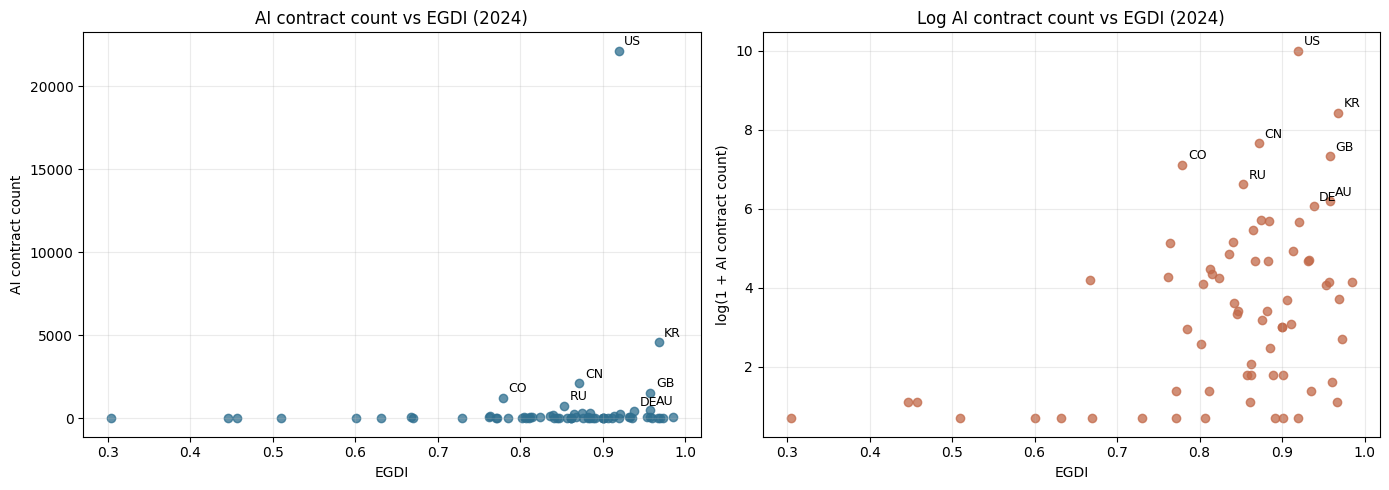

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(country_egdi_corr["egdi"], country_egdi_corr["ai_contracts"], alpha=0.75, color="#2F6F8F")
axes[0].set_title(f"AI contract count vs EGDI ({latest_egdi_year})")
axes[0].set_xlabel("EGDI")
axes[0].set_ylabel("AI contract count")
axes[0].grid(alpha=0.25)

axes[1].scatter(country_egdi_corr["egdi"], country_egdi_corr["log_ai_contracts"], alpha=0.75, color="#C26A4A")
axes[1].set_title(f"Log AI contract count vs EGDI ({latest_egdi_year})")
axes[1].set_xlabel("EGDI")
axes[1].set_ylabel("log(1 + AI contract count)")
axes[1].grid(alpha=0.25)

for _, row in country_egdi_corr.nlargest(8, "ai_contracts").iterrows():
    axes[0].annotate(row["country_iso2"], (row["egdi"], row["ai_contracts"]), fontsize=9, xytext=(4, 4), textcoords="offset points")
    axes[1].annotate(row["country_iso2"], (row["egdi"], row["log_ai_contracts"]), fontsize=9, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.show()

In [39]:
contract_country_year = (
    contract_country.dropna(subset=["country_iso3", "year"])
    .groupby(["country_iso2", "country_iso3", "year"], as_index=False)
    .agg(
        ai_contracts=("country_iso3", "size"),
        ai_contract_value_usd=("contract_value_usd", "sum"),
    )
)
contract_country_year["year"] = contract_country_year["year"].astype(int)

panel_corr = contract_country_year.merge(egdi, on=["country_iso3", "year"], how="inner")
panel_corr["log_ai_contracts"] = np.log1p(panel_corr["ai_contracts"])
panel_corr["log_ai_contract_value_usd"] = np.log1p(panel_corr["ai_contract_value_usd"].clip(lower=0))

print(f"Country-year observations in panel correlation sample: {len(panel_corr):,}")
print(f"Panel years: {panel_corr['year'].min()}-{panel_corr['year'].max()}")
panel_corr.sort_values(["year", "ai_contracts"], ascending=[False, False]).head(20)

Country-year observations in panel correlation sample: 219
Panel years: 2010-2024


,country_iso2,country_iso3,year,ai_contracts,ai_contract_value_usd,country_name,egdi,log_ai_contracts,log_ai_contract_value_usd
215,US,USA,2024,827,"2,918,279,731.48",United States,0.92,6.72,21.79
186,RU,RUS,2024,211,"31,766,379.84",Russian Federation,0.85,5.36,17.27
91,GB,GBR,2024,156,"25,725,170,695.83",United Kingdom,0.96,5.06,23.97
39,CO,COL,2024,129,"11,127,890.44",Colombia,0.78,4.87,16.22
38,CN,CHN,2024,67,"23,625,593.03",China,0.87,4.22,16.98
136,KR,KOR,2024,47,"5,232,305.04","Korea, Rep.",0.97,3.87,15.47
54,DE,DEU,2024,39,"6,571,965.61",Germany,0.94,3.69,15.70
206,UA,UKR,2024,32,"492,673.06",Ukraine,0.88,3.50,13.11
179,RO,ROU,2024,29,"100,198,905.81",Romania,0.76,3.40,18.42
170,PL,POL,2024,19,"2,235,435.74",Poland,0.86,3.00,14.62


In [40]:
panel_corr_vars = ["egdi", "ai_contracts", "log_ai_contracts", "ai_contract_value_usd", "log_ai_contract_value_usd"]

print("Country-year Pearson correlation")
display(panel_corr[panel_corr_vars].corr(method="pearson"))
print("Country-year Spearman correlation")
display(panel_corr[panel_corr_vars].corr(method="spearman"))

Country-year Pearson correlation


,egdi,ai_contracts,log_ai_contracts,ai_contract_value_usd,log_ai_contract_value_usd
egdi,1.00,0.16,0.34,0.13,0.39
ai_contracts,0.16,1.00,0.68,0.16,0.38
log_ai_contracts,0.34,0.68,1.00,0.25,0.60
ai_contract_value_usd,0.13,0.16,0.25,1.00,0.29
log_ai_contract_value_usd,0.39,0.38,0.60,0.29,1.00


Country-year Spearman correlation


,egdi,ai_contracts,log_ai_contracts,ai_contract_value_usd,log_ai_contract_value_usd
egdi,1.00,0.38,0.38,0.42,0.42
ai_contracts,0.38,1.00,1.00,0.73,0.73
log_ai_contracts,0.38,1.00,1.00,0.73,0.73
ai_contract_value_usd,0.42,0.73,0.73,1.00,1.00
log_ai_contract_value_usd,0.42,0.73,0.73,1.00,1.00


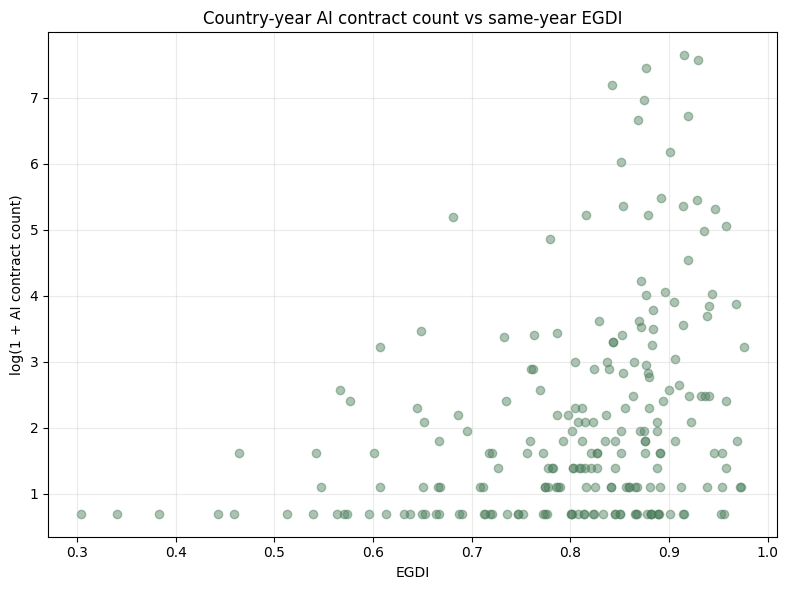

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(panel_corr["egdi"], panel_corr["log_ai_contracts"], alpha=0.45, color="#4A7C59")
ax.set_title("Country-year AI contract count vs same-year EGDI")
ax.set_xlabel("EGDI")
ax.set_ylabel("log(1 + AI contract count)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()